<a href="https://colab.research.google.com/github/Huii0529/Data-Science-Project/blob/main/P167347_Week12_DataLoading_Storage_20260606.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 12: <font color='red'>Data Loading and Storage</font>**

#### **For details of this Topic (Data Loading, Storage, and File Formats), please refer to the textbook: "Python for Data Analysis" by Wes McKinney: https://wesmckinney.com/book/**

#### **Mount to Google Drive**

In [35]:
# Mount to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Learning Objectives**

By the end of this lecture, students should be able to:

1. Load data from common file formats such as CSV, TXT, JSON, HTML, XML, Excel, Parquet, and SQL databases.
2. Identify and handle common data-loading issues such as missing values, delimiters, headers, and indexes.
3. Export pandas DataFrames into different file formats.
4. Understand the difference between human-readable formats such as CSV/JSON and binary formats such as Pickle/Parquet.
5. Retrieve structured data from online sources and Web APIs.

## **Import Pandas and NumPy libraries**


In [36]:
# Import the library
import pandas as pd
import numpy as np

# **<font color='red'>File format 1: CSV and TXT files**
### **Reading in and Writing Data in Text Format:** <font color='red'>\*.csv</font> or <font color='red'>\*.txt</font> **format**

# **csv -> comma separated value**

### **Method 1: Upload from Local PC to Google Drive**

In [37]:
# Download the ex1.csv file here: https://tinyurl.com/yheh3evw
# Upload ex1.csv to Google Drive
from google.colab import files
files.upload()

Saving ex1.csv to ex1 (1).csv


{'ex1 (1).csv': b'a,b,c,d,message\n1,2,3,4,hello\n5,6,7,8,world\n9,10,11,12,foo'}

## Shell Command
- A shell command is an **instruction** given to the computer's **operating system (OS)** through a command-line interpreter
- often called a **'shell'**.

In [38]:
# Check where is the ex1.csv file being uploaded
# pwd -> "present working directory"
!pwd

/content


In [39]:
# Reading a CSV file using read_table() without specifying the delimiter
# Since read_table() assumes tab-separated values by default, the CSV file is not separated correctly.
df = pd.read_table('/content/ex1.csv')
df

,"a,b,c,d,message"
0,"1,2,3,4,hello"
1,"5,6,7,8,world"
2,"9,10,11,12,foo"


In [40]:
# Correct method: specify comma as the delimiter
pd.read_table('/content/ex1.csv', sep = ',')

,a,b,c,d,message
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


### **Method 2: Reading data directly from github**

In [41]:
# Get ex1.csv from this URL: https://tinyurl.com/yc39yfdj
# Must be in RAW format
url = "https://raw.githubusercontent.com/mono0926/python-for-data-analytics/refs/heads/master/ch06/ex1.csv"

# Read using the read_csv() function
df = pd.read_csv(url)
df

,a,b,c,d,message
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


### **A file without header: ex2.csv**

In [42]:
# Download ex2.csv raw data directly from GitHub
# Using this URL: https://tinyurl.com/y4xd66my
# ex2.csv does not have header
# Python will assign column name automatically
url = 'https://tinyurl.com/y4xd66my'
df = pd.read_csv(url, header=None)
df

,0,1,2,3,4
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


In [43]:
# Specify the column names ourself
# Use this URL: https://tinyurl.com/y4xd66my
pd.read_csv(url, names=['UKM', 'fruit', 'num_car', 'fish', 'keywords'])

,UKM,fruit,num_car,fish,keywords
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


In [44]:
# Set which specific column as the index
# "names" -> expecting a list of strings representing the desired column names
# index_col -> the column used as the index (row labels) for the DataFrame
# Use this URL: https://tinyurl.com/y4xd66my
names=['a', 'book', 'cat', 'donkey', 'elephant']
pd.read_csv(url, names = names, index_col = 'elephant')

,a,book,cat,donkey
elephant,,,,
hello,1,2,3,4
world,5,6,7,8
foo,9,10,11,12


### **Table without a fixed delimiter**
- **sep=r'\s+'** denote one or more whitespace characters (**spaces, tabs, newlines**)
- `r` -> **raw string**

In [45]:
# Without indicating the delimiter
pd.read_table('https://tinyurl.com/2e2y7jh2')

,A B C
0,aaa -0.264438 -1.026059 -0.619500
1,bbb 0.927272 0.302904 -0.032399
2,ccc -0.264273 -0.386314 -0.217601
3,ddd -0.871858 -0.348382 1.100491


In [46]:
# Read a whitespace-separated table from a URL into a pandas DataFrame
res = pd.read_table('https://tinyurl.com/2e2y7jh2',
                    sep=r'\s+')
res

,A,B,C
aaa,-0.264438,-1.026059,-0.619500
bbb,0.927272,0.302904,-0.032399
ccc,-0.264273,-0.386314,-0.217601
ddd,-0.871858,-0.348382,1.100491


### **Files with comments embedded**

In [47]:
# Without dealing with the comments
pd.read_table('https://tinyurl.com/mr4ex879')

,# hey!
0,"a,b,c,d,message"
1,# just wanted to make things more difficult fo...
2,"# who reads CSV files with computers, anyway?"
3,"1,2,3,4,hello"
4,"5,6,7,8,world"
5,"9,10,11,12,foo"


In [48]:
# Load ex4.csv here: https://tinyurl.com/mr4ex879
# Using skip rows as parser function
pd.read_table('https://tinyurl.com/mr4ex879',
              skiprows = [0, 2, 3], sep = ',')

,a,b,c,d,message
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


In [49]:
# Another method: Use the "comment" function
# URL: https://bit.ly/3HXjXUR
pd.read_table('https://tinyurl.com/mr4ex879',
              comment = '#', sep = ',')

,a,b,c,d,message
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


# **Dealing with files with <font color='red'>missing data</font>**

### **Example dataset in RAW format**
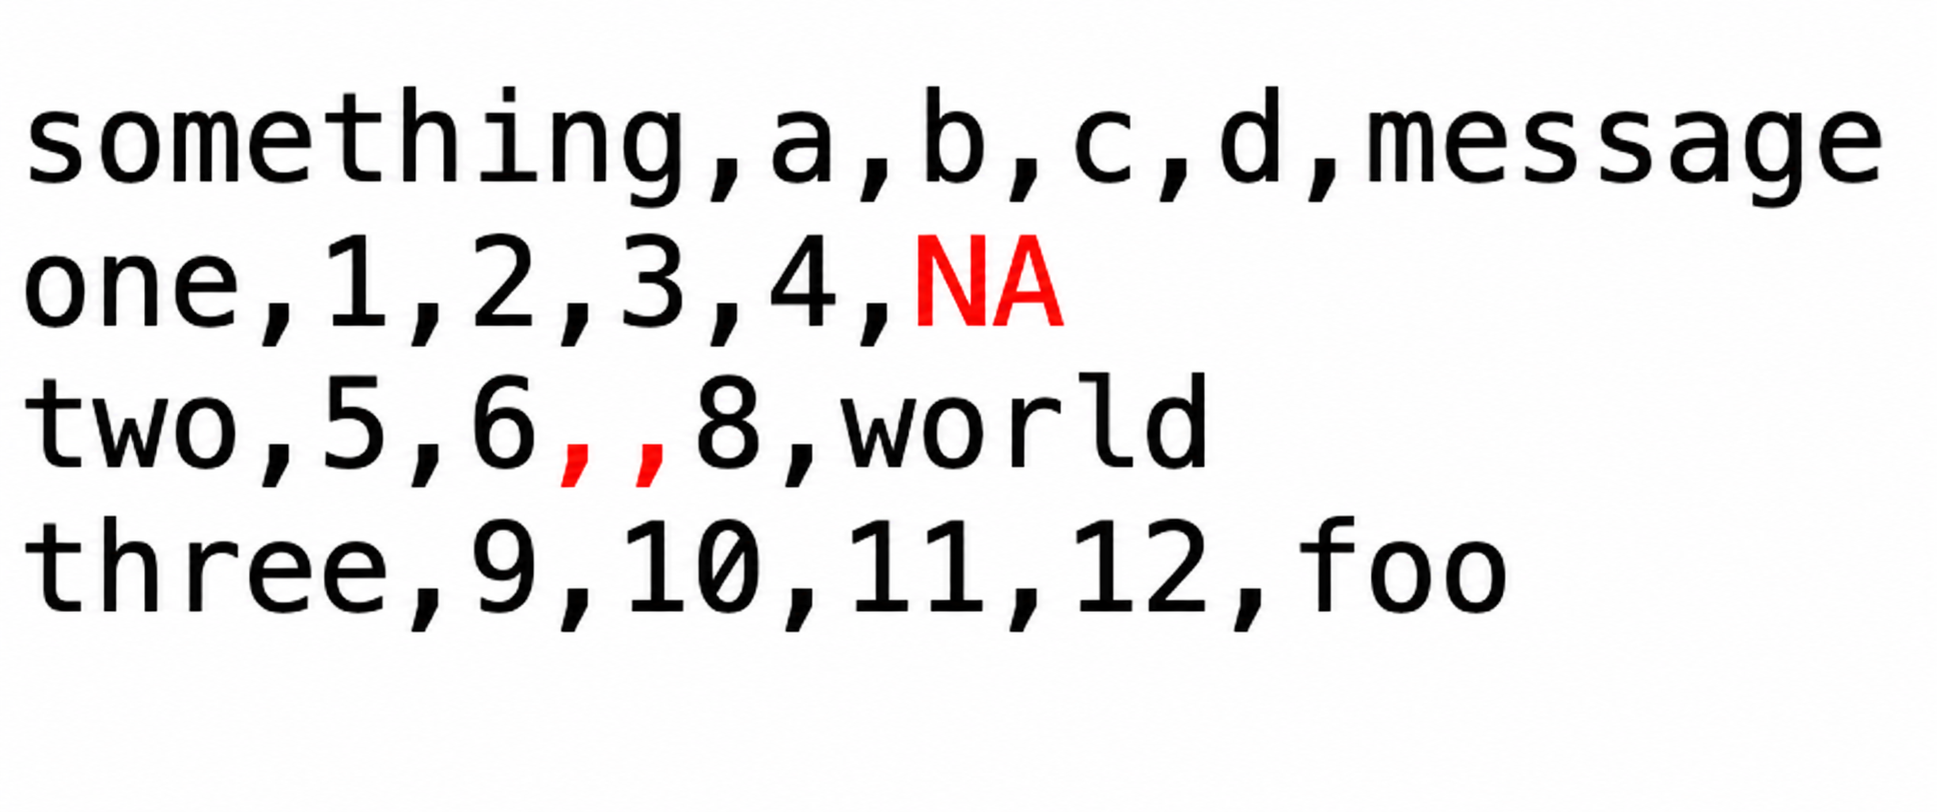

### **Why do missing values become NaN?**

When pandas reads a CSV file, it automatically treats certain values as missing data.

| Original value in CSV | How pandas interprets it |
|---|---|
| `NA` | Missing value |
| empty field such as `,,` | Missing value |
| `NULL` | Missing value if specified using `na_values=['NULL']` |

Therefore, pandas displays these missing values as `NaN`.

In [50]:
# Pandas automatically treats values such as "NA" and blank cells as missing values
# We can also add extra missing-value labels, such as "NULL", using na_values
res = pd.read_csv('https://tinyurl.com/yc4v35d6', na_values=['NULL'])
res

,something,a,b,c,d,message
0,one,1,2,3.0,4,NaN
1,two,5,6,NaN,8,world
2,three,9,10,11.0,12,foo


### **Notes:**
- Pandas converts both **`NA`** and **`,,`** into **`NaN`**


## **Sentinels**
* serve as **placeholders for specific conditions** or **special values** within pandas data structures.
* <font color='red'>`Missing data`: `NaN`</font> is the most common sentinel, representing **missing or undefined values**.
* `-999` will be place at the special placeholder

In [51]:
# Specified sentinels - unique placeholder values
# Get the raw data for ex5.csv here: https://tinyurl.com/yc4v35d6
print(res)
print("\n------------------------------------\n")

sentinels = {'message': ['foo'], 'something': ['two']}
pd.read_csv('https://tinyurl.com/yc4v35d6', na_values=sentinels)

  something  a   b     c   d message
0       one  1   2   3.0   4     NaN
1       two  5   6   NaN   8   world
2     three  9  10  11.0  12     foo

------------------------------------



,something,a,b,c,d,message
0,one,1,2,3.0,4,NaN
1,NaN,5,6,NaN,8,world
2,three,9,10,11.0,12,NaN


## **Reading Text Files in Pieces**
### When ***processing very large files***, we may want to read only a small piece of a file

In [52]:
# Change pandas display settings to become more compact
# Setting the maximum number of rows to 8
pd.options.display.max_rows=8

In [53]:
# Read a large csv file - display only six rows
# Download ex6.csv here: https://tinyurl.com/3dv6buw8
# pd.options.display.max_rows=8
res = pd.read_csv('https://tinyurl.com/3dv6buw8')
res

,one,two,three,four,key
0,0.467976,-0.038649,-0.295344,-1.824726,L
1,-0.358893,1.404453,0.704965,-0.200638,B
2,-0.501840,0.659254,-0.421691,-0.057688,G
3,0.204886,1.074134,1.388361,-0.982404,R
...,...,...,...,...,...
9996,-0.479893,-0.650419,0.745152,-0.646038,E
9997,0.523331,0.787112,0.486066,1.093156,K
9998,-0.362559,0.598894,-1.843201,0.887292,G
9999,-0.096376,-1.012999,-0.657431,-0.573315,0


In [54]:
# Reset the maximum number of displayed rows to the pandas default setting
pd.reset_option('display.max_rows')

In [55]:
# Only display a small number of rows
pd.read_csv('https://tinyurl.com/3dv6buw8')

,one,two,three,four,key
0,0.467976,-0.038649,-0.295344,-1.824726,L
1,-0.358893,1.404453,0.704965,-0.200638,B
2,-0.501840,0.659254,-0.421691,-0.057688,G
3,0.204886,1.074134,1.388361,-0.982404,R
4,0.354628,-0.133116,0.283763,-0.837063,Q
...,...,...,...,...,...
9995,2.311896,-0.417070,-1.409599,-0.515821,L
9996,-0.479893,-0.650419,0.745152,-0.646038,E
9997,0.523331,0.787112,0.486066,1.093156,K
9998,-0.362559,0.598894,-1.843201,0.887292,G


## **Write the data**

In [56]:
# Read ex5.csv: https://tinyurl.com/yc4v35d6
dat = pd.read_csv('https://tinyurl.com/yc4v35d6')
dat

,something,a,b,c,d,message
0,one,1,2,3.0,4,NaN
1,two,5,6,NaN,8,world
2,three,9,10,11.0,12,foo


In [57]:
# Save the file to the current Colab working directory
dat.to_csv('/content/ex5_output.csv', index=False)

In [58]:
# Display the saved file
!cat /content/ex5_output.csv

something,a,b,c,d,message
one,1,2,3.0,4,
two,5,6,,8,world
three,9,10,11.0,12,foo


### **Working with Other Delimited Formats**

In [59]:
# Other delimiters: using a pipe "|" or "@" or "^"
# sys.stdout means "system.standard output", usually the notebook output area
# Here, to_csv() prints the CSV-formatted data to the screen instead of saving it to a file
import sys
dat.to_csv(sys.stdout, sep='%')

%something%a%b%c%d%message
0%one%1%2%3.0%4%
1%two%5%6%%8%world
2%three%9%10%11.0%12%foo


In [60]:
# Fill missing data with some string representation
# na_rep: missing data representation
dat.to_csv(sys.stdout, na_rep='hilang')

,something,a,b,c,d,message
0,one,1,2,3.0,4,hilang
1,two,5,6,hilang,8,world
2,three,9,10,11.0,12,foo


In [61]:
# Disable row and column label
dat.to_csv(sys.stdout, index = False, header = False)

one,1,2,3.0,4,
two,5,6,,8,world
three,9,10,11.0,12,foo


In [62]:
# Write subset of the dataframe: a, b, c
print(dat)
print("\n------------------------------------\n")

dat.to_csv(sys.stdout, index = False, columns = ['a', 'b', 'c'])

  something  a   b     c   d message
0       one  1   2   3.0   4     NaN
1       two  5   6   NaN   8   world
2     three  9  10  11.0  12     foo

------------------------------------

a,b,c
1,2,3.0
5,6,
9,10,11.0


### **Notes:**
- **`sys.stdout`** means "print the output to the screen"
- it displays the CSV-formatted data directly in the output cell

# **<font color='red'>Working with Date and Time Data</font>**

### **Pandas Series is a one-dimensional labeled array**
* the associated array of labels is called the **index**
* capable of holding data of any type
    * <font color='red'>***integer, string, float, python objects***</font>, etc

In [63]:
# By default, international accepted date format: YYYY-MM-DD
dates = pd.date_range('06-06-2026', periods = 7)
dates

DatetimeIndex(['2026-06-06', '2026-06-07', '2026-06-08', '2026-06-09',
               '2026-06-10', '2026-06-11', '2026-06-12'],
              dtype='datetime64[ns]', freq='D')

In [65]:
# Pandas can incorporate NumPy function -> np.arange
# np.arange returned an array range instead of list
dates = pd.date_range('06/06/2026', periods = 7)
ts = pd.Series(np.arange(7), index = dates)

# Save it to your own folder
ts.to_csv('/content/tseries01.csv')

### **Convert string to date format**

In [66]:
# To specify the exact date format
date_string = '06-26@06'
date_format = '%d-%y@%m'

# Convert the date string to a datetime object
start_date = pd.to_datetime(date_string, format = date_format)

# Generate a date range with specified start date and periods
date_range = pd.date_range(start_date, periods = 7)

# Output the date range
print(date_range)

DatetimeIndex(['2026-06-06', '2026-06-07', '2026-06-08', '2026-06-09',
               '2026-06-10', '2026-06-11', '2026-06-12'],
              dtype='datetime64[ns]', freq='D')


In [67]:
# Starts June 06 (Sat), for seven periods;
# Week start on Wednesday
dates = pd.date_range('06/06/2026', periods = 7, freq = ('W-WED'))
dates

DatetimeIndex(['2026-06-10', '2026-06-17', '2026-06-24', '2026-07-01',
               '2026-07-08', '2026-07-15', '2026-07-22'],
              dtype='datetime64[ns]', freq='W-WED')

# **<font color='red'>File format 2: JSON files</font>**

### **JSON Data format** - short for ***J***ava***S***cript ***O***bject ***N***otation
1. one of the standard formats for sending data by HTTP request between web
browsers and other applications
2. much more free-form data format than a tabular text form like CSV
3. basic types are objects (***dictionaries***), arrays (***lists***), strings, numbers, Booleans, and nulls.
4. <font color='red'>all of the ***keys*** in an object must be ***strings***</font>
5. **values** can be any type: (Date, Time, String, Float, Int, List, Dictionaries, etc.)

In [69]:
# Triple quote -> """ -> docstring
obj = """
{"name": "Wes",
  "cities_lived": ["Akron", "Nashville", "New York", "San Francisco"],
  "pet": null,
  "siblings": [{"name": "Scott", "age": 34, "hobbies": ["guitars", "soccer"]},
               {"name": "Katie", "age": 42, "hobbies": ["diving", "art"]}]
}
"""

In [72]:
# Convert the JSON-formatted string into a Python dictionary (json.loads())
# res is now a dictionary containing the parsed JSON data
import json
res = json.loads(obj)
res

{'name': 'Wes',
 'cities_lived': ['Akron', 'Nashville', 'New York', 'San Francisco'],
 'pet': None,
 'siblings': [{'name': 'Scott', 'age': 34, 'hobbies': ['guitars', 'soccer']},
  {'name': 'Katie', 'age': 42, 'hobbies': ['diving', 'art']}]}

In [73]:
# Converts Python object back to JSON (json.dumps())
json.dumps(res)

'{"name": "Wes", "cities_lived": ["Akron", "Nashville", "New York", "San Francisco"], "pet": null, "siblings": [{"name": "Scott", "age": 34, "hobbies": ["guitars", "soccer"]}, {"name": "Katie", "age": 42, "hobbies": ["diving", "art"]}]}'

In [74]:
# Convert the "siblings" list from the JSON object into a pandas DataFrame
siblings = pd.DataFrame(res["siblings"], columns = ['name', 'hobbies'])
siblings

,name,hobbies
0,Scott,"[guitars, soccer]"
1,Katie,"[diving, art]"


In [76]:
# Extract the city information and display in a dataframe
pd.DataFrame(res["cities_lived"], columns = ['CityInfo'])

,CityInfo
0,Akron
1,Nashville
2,New York
3,San Francisco


# **<font color='red'>File format 3: HTML files</font>**

### **HTML file format**
1. The **`pandas.read_html()`** function by default searches for and attempts to parse all ***tabular data*** contained within ***\<table>*** tags.
2. The result is a ***list of DataFrame objects***

In [ ]:
# Download data here: https://tinyurl.com/msaka5pd
# The filename: fdic_failed_bank_list.html
# fdic -> Federal Deposit Insurance Corporation
# This is a list of banks which have failed since October 1, 2000.
# The output is a list containing extracted tables (as DataFrames) -> []
tbls = pd.read_html('https://tinyurl.com/msaka5pd')
tbls

In [ ]:
# Check how many tables were extracted
print(len(tbls))

In [ ]:
# Output the content of the table
failures = tbls[0]
failures

### **Explanation:**
**`pd.read_html()`** returns a list of DataFrames because one HTML page may contain many tables.  

- Since Python indexing starts from 0, **`tbls[0]`** refers to the first extracted table.

In [ ]:
# Perform data cleaning and analysis
# Extract data from "Closing Date" column
# Convert to standard date accepted internationally
close_timestamps = pd.to_datetime(failures["Closing Date"])
close_timestamps

In [ ]:
# Count frequency of banks closed for each year starting from Oct 1, 2000
# dt -> DatetimeProperties
year_counts = close_timestamps.dt.year.value_counts()
year_counts

In [ ]:
# Sort the years (index) in ascending order and filter for years from 2000
filtered_and_sorted_counts = year_counts[year_counts.index >= 2000].sort_index()
display(filtered_and_sorted_counts)

### **Insights:**
The high number of bank closures in 2010 was mainly due to the **delayed impact of the 2008 financial crisis and recession**.
- Many U.S. banks had high exposure to risky real-estate-related loans, especially commercial real estate and construction/development loans.
- When property values fell and borrowers defaulted, these banks suffered large loan losses.
- As a result, many smaller and regional banks became insolvent, causing bank failures to peak in 2010.

# **<font color='red'>File format 4: XML files</font>**

# **XML (Extensible Markup Language)**
- XML provides a flexible and powerful way to **represent and exchange data** in a **structured, <font color='red'>human-readable, and machine-readable</font>** format.
- It's a foundational technology used in various domains, from web development to data analysis.
- **Does not have predefined tags**; we can define our own tags (e.g., **\<book>**, **\<author>**, **\<product>**)
- making XML **'extensible'** because we can extend it to define any data structure we need.
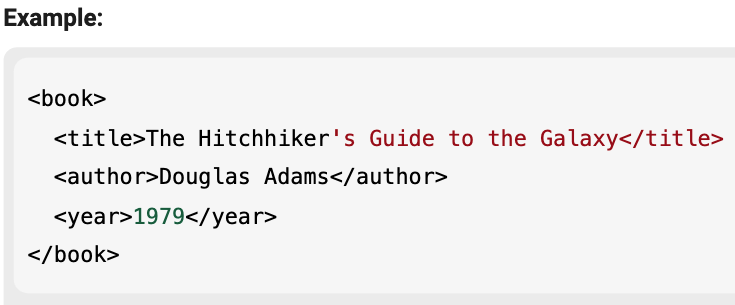

### **Parsing XML with `lxml.objectify`**
1. parse the file and get a reference to the root node of the XML file with getroot, i.e. ***the document node***
2. If we were describing a book using XML, for example, the root element might be **\<book>** and everything related to that book—like **\<title>**, **\<author>**, and **\<content>**—would be nested within it.

3. The root element essentially provides the overall structure and context for the rest of the information in the XML document.

# **Click here for more information about XML: https://tinyurl.com/3zdf4hab**

In [ ]:
import requests
from lxml import objectify

# Raw GitHub URL for the XML file
url = "https://tinyurl.com/4atyt7cc"

# Download the XML content from GitHub
response = requests.get(url)

# Stop the program and show an error if the URL request failed
response.raise_for_status()

# Parse the XML content
root = objectify.fromstring(response.content)

### **XML elements**
- The XML file contains many repeated `<INDICATOR>` elements.  
- Each `<INDICATOR>` stores one performance record.  
- The loop below extracts each XML element and converts it into a Python dictionary.  
- Finally, all dictionaries are stored in a list and converted into a pandas DataFrame.

In [ ]:
# Convert XML records into a list of dictionaries
data = []

# These fields will be excluded from the final DataFrame
skip_fields = ['PARENT_SEQ', 'INDICATOR_SEQ',
               'DESIRED_CHANGE', 'DECIMAL_PLACES']

for elt in root.INDICATOR:
    # Store one XML record as a dictionary
    elt_data = {}

    for child in elt.getchildren():
        # Skip selected fields
        if child.tag in skip_fields:
            continue

        # Use the XML tag as the dictionary key and the XML value as the dictionary value
        elt_data[child.tag] = child.pyval

    # Add the extracted record to the list
    data.append(elt_data)

In [ ]:
# Convert the list into a pandas DataFrame
perf = pd.DataFrame(data)
perf

# **<font color='red'>File format 5: BINARY files</font>**

### **Binary data files**

- Binary file is not human-readable

In [ ]:
# CSV Data Formats
frame = pd.read_csv('/content/ex1.csv')
frame

### **Pickle format**
- converting data structures like lists, dictionaries, class instances, and more **into a byte stream** that can be stored in a file or transmitted over a network.

### <font color='red'>**Important security note**

- Pickle files should only be loaded from trusted sources.  

- Unlike CSV or JSON, Pickle can store executable Python object instructions.  
- Opening an unknown Pickle file may be unsafe.

In [ ]:
# Pickle stores Python objects in binary form
# Store data in binary format using Python's built-in pickle function
frame.to_pickle('/content/frame_pickle')

### **Explanation**
- Pickle does not save the data as a normal readable text file like CSV.
- Instead, it saves the object in a binary format that Python can understand later
- Pickle is useful when we want to save a Python object exactly as it is, but it is not suitable for sharing data with non-Python users.

In [ ]:
# If you really want to see what the pickle file looked like
!cat /content/frame_pickle

### **Explanation**
- The file looks messy.
- It is not meant to be read by humans.
- It is meant to be read by Python.

In [ ]:
# read pickle files
pd.read_pickle('/content/frame_pickle')

### **Parquet format**
- **open-source, column-oriented data storage format** designed for efficient data processing and analytics.
- widely used in big data ecosystems like **Hadoop, Spark, and Hive**, as well as in cloud data warehouses like Amazon Redshift and Google BigQuery

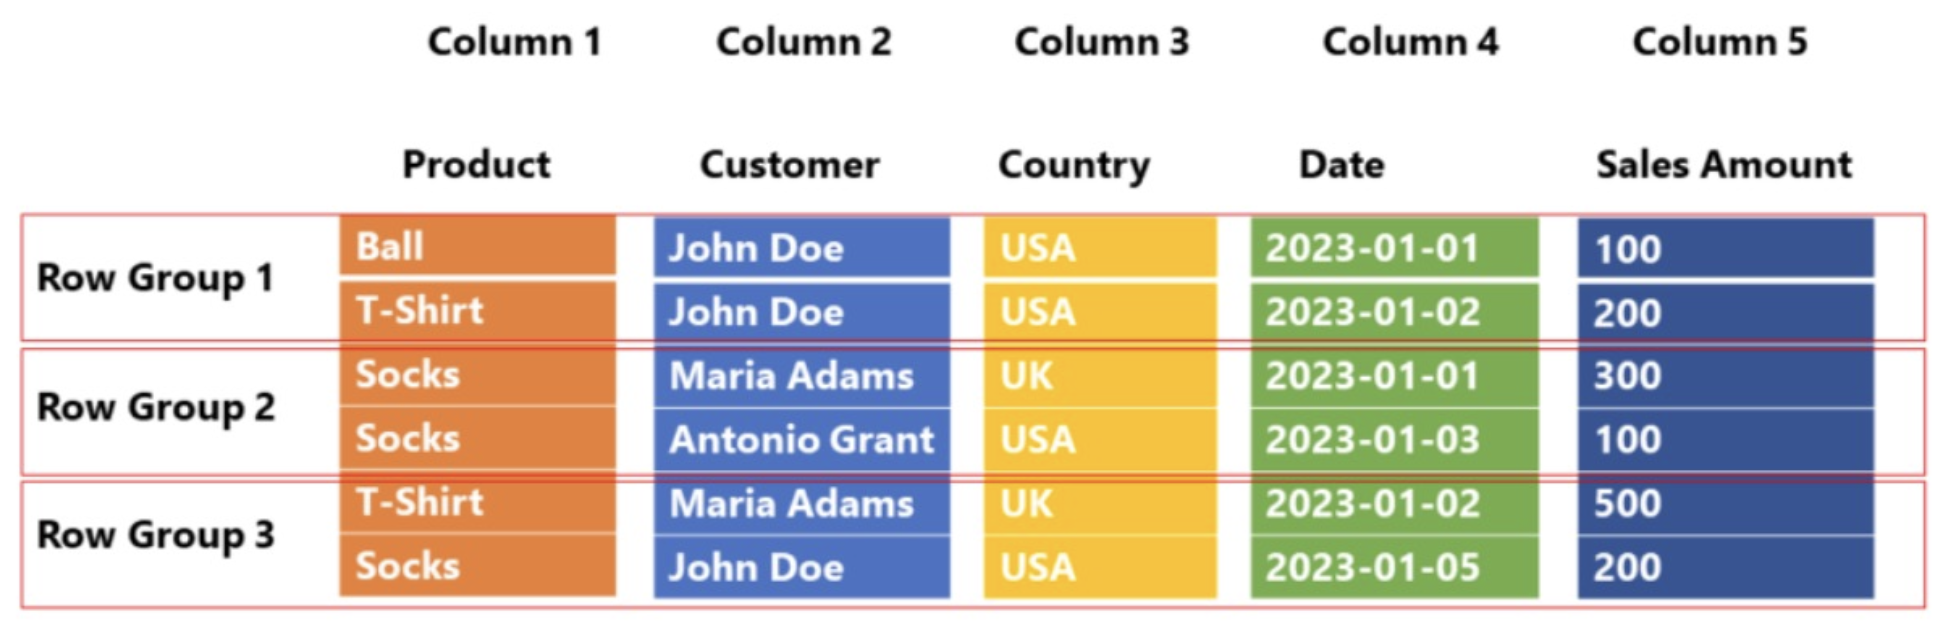

### **CSV vs Pickle vs Parquet**

| Format | Human-readable? | Best used for |
|---|---|---|
| CSV | Yes | Simple data exchange |
| Pickle | No | Saving Python objects for later use in Python |
| Parquet | No | Efficient storage and processing of large tabular datasets |

### **Download the parquet file (fec.parquet) here: https://tinyurl.com/4t56bxjy**
- Before running the next cell, upload **`fec.parquet`** to the Colab **`/content/`** directory.
- using the upload button

In [ ]:
# Read the parquet file after uploading it to Colab
fec = pd.read_parquet('/content/fec.parquet')
fec

# **<font color='red'>File format 6: Excel files</font>**

### **Reading Excel files**

In [ ]:
# Download the ex1.xlsx here: https://tinyurl.com/359uwbk9
xlsx = pd.ExcelFile("https://tinyurl.com/359uwbk9")

In [ ]:
# Getting excel sheet name
xlsx.sheet_names

In [ ]:
# Retrieve data by providing sheet name
xlsx.parse(sheet_name = 'Sheet1')

In [ ]:
# Without index column
xlsx.parse(sheet_name = 'Sheet1', index_col = 0)

In [ ]:
# Another way of reading the ex1.xlsx file
frame = pd.read_excel('https://tinyurl.com/359uwbk9')
frame

### **Writing DataFrames to Excel files**


In [ ]:
# Output the frame content
frame

In [ ]:
# Optimized way to write xlsx file
frame.to_excel("/content/drive/MyDrive/STQD6014_Executive/_SEM2_20252026/Data/ex2_optimized.xlsx", sheet_name="bernard", index=False)

# **<font color='red'>File format 7: WEB API files</font>**

### **Interacting with Web APIs**
1. Web API is a ***System to System interaction***, in which the ***data*** or information from one system ***can be accessed*** by another system, after the completion of execution the output is ***shown to the viewer***.

### **Note:**
- Web API results are dynamic. The output may be different when the code is run on a different day because GitHub issues are continuously updated.

### ***Task: To find the latest 30 GitHub issues for pandas on GitHub***

In [ ]:
# first get the URL link: https://tinyurl.com/36ttfwsw
url = 'https://tinyurl.com/36ttfwsw'

In [ ]:
# Import requests to retrieve data from the Web API
import requests

# Get the data
resp = requests.get(url)

# **To understand more about HTTP status, visit this link**: http://tinyurl.com/5cm2yhcw

In [ ]:
# Check for the API status
resp.raise_for_status()
resp

In [ ]:
# Return a dictionary containing JSON parsed into native Python objects:
data = resp.json() # This is in json format
data[0]

In [ ]:
# Get the first data under title
data[0]["number"]

In [ ]:
# Pass data directly to DataFrame and extract fields of interest:
issues = pd.DataFrame(data, columns = ['id', 'number', 'title', 'labels', 'state'])
issues

# **<font color='red'>File format 8: SQL files</font>**

### **Interacting with Databases - SQL**
- Create tables with Schema
- Schema -> data type and format for each fields
- Commit
- Then only insert data
- Schema on Write




In [ ]:
# SQL
import sqlite3

In [ ]:
# Connect to a SQLite3 database using a 'with' statement for automatic resource management
# This ensures the connection is properly closed even if errors occur.
with sqlite3.connect('/content/mydata.sqlite') as con:
    # Drop the table if it already exists to avoid duplicate rows
    con.execute("DROP TABLE IF EXISTS test")

    # Create the SQL query for table creation
    query = """
    CREATE TABLE test
    (a VARCHAR(20), b VARCHAR(20),
    c REAL, d INTEGER
    );"""

    # Execute the table creation query and commit the changes
    con.execute(query)

    # Create some data to insert
    data = [("Atlanta", "Georgia", 1.25, 6),
            ("Bangi", "Jalan Reko", 3.3, 5),
            ("Seremban", "Nilai", 5.5, 89)]

    # Create a query statement for inserting data
    # sqlite3 module will replace each ? with a corresponding value from a Python sequence (like a tuple or list)
    stmt = "INSERT INTO test VALUES(?, ?, ?, ?)"

    # Execute the insert statement for multiple rows and commit the changes
    # 'executemany' is efficient for inserting multiple records
    con.executemany(stmt, data)

    # Select all data from the 'test' table
    rows = con.execute("SELECT * FROM test").fetchall()

# Print rows to see the fetched data after the 'with' block is exited
rows

## **Summary of File Formats**

| Format | Function to read | Function to write | Human-readable? |
|---|---|---|---|
| CSV | `pd.read_csv()` | `df.to_csv()` | Yes |
| TXT | `pd.read_table()` | `df.to_csv()` | Yes |
| JSON | `json.loads()`, `pd.read_json()` | `json.dumps()` | Yes |
| HTML | `pd.read_html()` | - | Yes, but structured for web pages |
| XML | `objectify.fromstring()` | - | Yes, but nested |
| Pickle | `pd.read_pickle()` | `df.to_pickle()` | No |
| Parquet | `pd.read_parquet()` | `df.to_parquet()` | No |
| Excel | `pd.read_excel()` | `df.to_excel()` | Partly |
| SQL | `pd.read_sql()` / `sqlite3` | SQL `INSERT` | No, database-based |
| Web API | `requests.get()` | - | Usually JSON |

# **Done for the day!!!**

Your Job: convert these code into Jupyter NoteBook executable code for preparation for the final exam